# DIA - Label-Free

This tutorial demonstrates how to analyze label-free quantification (LFQ) data from data-independent acquisition (DIA) using the `msmu` package.

## Data Preparation

Original dataset is from [PXD012988](https://www.ebi.ac.uk/pride/archive/projects/PXD012988) (Uszkoreit _et al_., 2022) and search was performed with [`DIA-NN` v2.1.0](https://github.com/vdemichev/DiaNN/releases/tag/2.0).

For demonstration purposes, the example dataset was reduced to six samples and a total of 1,000 peptides.


In [2]:
base_dir = "https://raw.githubusercontent.com/bertis-informatics/msmu/refs/heads/dev/data/diann_dia"
diann_idents = f"{base_dir}/diann/report.parquet"
sdrf = f"{base_dir}/meta.sdrf.tsv"

## Load Required Packages

> If you haven't installed the `msmu` package yet, please follow the [installation guide](../../installation/).


In [3]:
import msmu as mm
import plotly.io as pio

pio.renderers.default = "png"

## Read Data

You can read data from various proteomics software outputs. Below are examples for `DIA-NN`, `MaxQuant`, and `FragPipe` formats.

For this tutorial, we will use `DIA-NN` output as an example.

`read_diann()` function reads `DIA-NN` output file (`report.parquet` or `report.tsv`) and creates modalities at MuData object.


In [6]:
# DIA-NN format
mdata = mm.read_diann(identification_file=diann_idents)

# MaxQuant format
# mdata = mm.read_maxquant(identification_file="path_to_maxquant_output", label="label_free", acquisition="dia")

# FragPipe format
# mdata = mm.read_fragpipe(identification_file="path_to_fragpipe_output", label="label_free", acquisition="dia")

# Sample metadata from the SDRF: keep the table on the container, then project it onto obs
mdata = mm.pp.attach_sdrf(mdata, sdrf)
mdata = mm.pp.apply_sdrf_to_obs(mdata)

mdata.obs
# Without an SDRF, add_meta() joins any table (DataFrame, csv, tsv, parquet) onto obs instead:
# mdata = mm.pp.add_meta(mdata, sdrf, format="sdrf", metadata_on="assay name")

INFO - Validating SDRF metadata for https://raw.githubusercontent.com/bertis-informatics/msmu/refs/heads/dev/data/diann_dia/meta.sdrf.tsv.
INFO - SDRF validation succeeded for https://raw.githubusercontent.com/bertis-informatics/msmu/refs/heads/dev/data/diann_dia/meta.sdrf.tsv.


,source name,characteristics[organism],characteristics[organism part],characteristics[cell line],characteristics[cell type],characteristics[cellosaurus accession],characteristics[cellosaurus name],characteristics[disease],characteristics[biological replicate],assay name,technology type,comment[proteomexchange accession number],comment[proteomics data acquisition method],comment[fraction identifier],comment[technical replicate],comment[label],comment[instrument],comment[cleavage agent details],factor value[condition]
QExHF03751,G1-1,Mus musculus,not available,C2C12,myoblast,CVCL_0188,C2C12,normal,1,QExHF03751,proteomic profiling by mass spectrometry,PXD012988,data-independent acquisition,1,1,label free sample,Q Exactive HF,NT=Trypsin;AC=MS:1001251,G1
QExHF03753,G2-1,Mus musculus,not available,C2C12,myoblast,CVCL_0188,C2C12,normal,1,QExHF03753,proteomic profiling by mass spectrometry,PXD012988,data-independent acquisition,1,1,label free sample,Q Exactive HF,NT=Trypsin;AC=MS:1001251,G2
QExHF03761,G1-2,Mus musculus,not available,C2C12,myoblast,CVCL_0188,C2C12,normal,2,QExHF03761,proteomic profiling by mass spectrometry,PXD012988,data-independent acquisition,1,1,label free sample,Q Exactive HF,NT=Trypsin;AC=MS:1001251,G1
QExHF03763,G2-2,Mus musculus,not available,C2C12,myoblast,CVCL_0188,C2C12,normal,2,QExHF03763,proteomic profiling by mass spectrometry,PXD012988,data-independent acquisition,1,1,label free sample,Q Exactive HF,NT=Trypsin;AC=MS:1001251,G2
QExHF03771,G1-3,Mus musculus,not available,C2C12,myoblast,CVCL_0188,C2C12,normal,3,QExHF03771,proteomic profiling by mass spectrometry,PXD012988,data-independent acquisition,1,1,label free sample,Q Exactive HF,NT=Trypsin;AC=MS:1001251,G1
QExHF03773,G2-3,Mus musculus,not available,C2C12,myoblast,CVCL_0188,C2C12,normal,3,QExHF03773,proteomic profiling by mass spectrometry,PXD012988,data-independent acquisition,1,1,label free sample,Q Exactive HF,NT=Trypsin;AC=MS:1001251,G2


In [5]:
mdata

MuData object with n_obs × n_vars = 6 × 5038
  obs:	'source name', 'characteristics[organism]', 'characteristics[organism part]', 'characteristics[cell line]', 'characteristics[cell type]', 'characteristics[cellosaurus accession]', 'characteristics[cellosaurus name]', 'characteristics[disease]', 'characteristics[biological replicate]', 'assay name', 'technology type', 'comment[proteomexchange accession number]', 'comment[proteomics data acquisition method]', 'comment[fraction identifier]', 'comment[technical replicate]', 'comment[label]', 'comment[instrument]', 'comment[cleavage agent details]', 'factor value[condition]'
  uns:	'_cmd', 'sdrf'
  1 modality
    psm:	6 × 5038
      obs:	'source name', 'characteristics[organism]', 'characteristics[organism part]', 'characteristics[cell line]', 'characteristics[cell type]', 'characteristics[cellosaurus accession]', 'characteristics[cellosaurus name]', 'characteristics[disease]', 'characteristics[biological replicate]', 'assay name', 'technology type', 'comment[proteomexchange accession number]', 'comment[proteomics data acquisition method]', 'comment[fraction identifier]', 'comment[technical replicate]', 'comment[label]', 'comment[instrument]', 'comment[cleavage agent details]', 'factor value[condition]'
      var:	'proteins', 'peptide', 'stripped_peptide', 'filename', 'charge', 'peptide_length', 'rt', 'decoy', 'contaminant', 'PEP', 'q_value'
      uns:	'level', 'search_engine', 'quantification', 'label', 'acquisition', 'identification_file', 'quantification_file', 'decoy'
      varm:	'search_result'
      layers:	None

### Saving Raw MuData Object

After reading the search output, saving the MuData object as an `h5mu` file is recommended for future use.


In [7]:
mdata.write_h5mu("dia_lfq_PXD012988_raw.h5mu")

## Handling PSM level

> **If you are using `DIA-NN` version under 2.0, or the data doesn't contain decoy features, please jump to this [section](#for-dia-nn-without-decoy).**

### Filtering - PSM

You can filter the data based on the column values, such as q-value.
You can also filter on the flags the reader records, such as `contaminant`, or on string containment.

Filtering is split into two steps: first, you mark a filter condition using `mm.pp.add_filter()`, and then you apply the filter using `mm.pp.apply_filter()`.

Here, we keep protein groups with q-value < 0.01.


In [8]:
mdata = mm.pp.add_filter(mdata, modality="psm", column="q_value", keep="lt", value=0.01)
mdata = mm.pp.apply_filter(mdata, modality="psm")

mdata

INFO - Applying var filters for psm: ['q_value_lt_0.01']


MuData object with n_obs × n_vars = 6 × 5038
  obs:	'source name', 'characteristics[organism]', 'characteristics[organism part]', 'characteristics[cell line]', 'characteristics[cell type]', 'characteristics[cellosaurus accession]', 'characteristics[cellosaurus name]', 'characteristics[disease]', 'characteristics[biological replicate]', 'assay name', 'technology type', 'comment[proteomexchange accession number]', 'comment[proteomics data acquisition method]', 'comment[fraction identifier]', 'comment[technical replicate]', 'comment[label]', 'comment[instrument]', 'comment[cleavage agent details]', 'factor value[condition]'
  uns:	'_cmd', 'sdrf'
  1 modality
    psm:	6 × 5038
      obs:	'source name', 'characteristics[organism]', 'characteristics[organism part]', 'characteristics[cell line]', 'characteristics[cell type]', 'characteristics[cellosaurus accession]', 'characteristics[cellosaurus name]', 'characteristics[disease]', 'characteristics[biological replicate]', 'assay name', 'technology type', 'comment[proteomexchange accession number]', 'comment[proteomics data acquisition method]', 'comment[fraction identifier]', 'comment[technical replicate]', 'comment[label]', 'comment[instrument]', 'comment[cleavage agent details]', 'factor value[condition]'
      var:	'proteins', 'peptide', 'stripped_peptide', 'filename', 'charge', 'peptide_length', 'rt', 'decoy', 'contaminant', 'PEP', 'q_value'
      uns:	'level', 'search_engine', 'quantification', 'label', 'acquisition', 'identification_file', 'quantification_file', 'decoy', 'filter', 'decoy_filter'
      varm:	'search_result', 'filter'
      layers:	None

### Normalization

Here, we log2 transform and normalize the data at the PSM level.

Median centering normalization is applied using `mm.pp.normalize()` function.


In [12]:
mdata = mm.pp.log2_transform(mdata, modality="psm")
mdata = mm.pp.normalize(mdata, modality="psm", method="median")

## Handling peptide level

### Summarization - peptide

You can summarize psm-level data to peptide-level data using the `mm.pp.to_peptide()` function.


In [13]:
mdata = mm.pp.to_peptide(mdata)

INFO - Peptide-level identifications: 982 (966 at 1% FDR)
INFO - Building new peptide quantification data.


### Filtering - peptide


In [14]:
mdata = mm.pp.add_filter(mdata, modality="peptide", column="q_value", keep="lt", value=0.01)
mdata = mm.pp.apply_filter(mdata, modality="peptide", on="var")

mdata

INFO - Applying var filters for peptide: ['q_value_lt_0.01']


MuData object with n_obs × n_vars = 6 × 6004
  obs:	'source name', 'characteristics[organism]', 'characteristics[organism part]', 'characteristics[cell line]', 'characteristics[cell type]', 'characteristics[cellosaurus accession]', 'characteristics[cellosaurus name]', 'characteristics[disease]', 'characteristics[biological replicate]', 'assay name', 'technology type', 'comment[proteomexchange accession number]', 'comment[proteomics data acquisition method]', 'comment[fraction identifier]', 'comment[technical replicate]', 'comment[label]', 'comment[instrument]', 'comment[cleavage agent details]', 'factor value[condition]'
  uns:	'_cmd', 'sdrf'
  2 modalities
    psm:	6 × 5038
      obs:	'source name', 'characteristics[organism]', 'characteristics[organism part]', 'characteristics[cell line]', 'characteristics[cell type]', 'characteristics[cellosaurus accession]', 'characteristics[cellosaurus name]', 'characteristics[disease]', 'characteristics[biological replicate]', 'assay name', 'technology type', 'comment[proteomexchange accession number]', 'comment[proteomics data acquisition method]', 'comment[fraction identifier]', 'comment[technical replicate]', 'comment[label]', 'comment[instrument]', 'comment[cleavage agent details]', 'factor value[condition]'
      var:	'proteins', 'peptide', 'stripped_peptide', 'filename', 'charge', 'peptide_length', 'rt', 'decoy', 'contaminant', 'PEP', 'q_value'
      uns:	'level', 'search_engine', 'quantification', 'label', 'acquisition', 'identification_file', 'quantification_file', 'decoy', 'filter', 'decoy_filter'
      varm:	'search_result', 'filter'
      layers:	None
    peptide:	6 × 966
      obs:	'source name', 'characteristics[organism]', 'characteristics[organism part]', 'characteristics[cell line]', 'characteristics[cell type]', 'characteristics[cellosaurus accession]', 'characteristics[cellosaurus name]', 'characteristics[disease]', 'characteristics[biological replicate]', 'assay name', 'technology type', 'comment[proteomexchange accession number]', 'comment[proteomics data acquisition method]', 'comment[fraction identifier]', 'comment[technical replicate]', 'comment[label]', 'comment[instrument]', 'comment[cleavage agent details]', 'factor value[condition]'
      var:	'peptide', 'proteins', 'stripped_peptide', 'count_psm', 'PEP', 'q_value'
      uns:	'level', 'decoy', 'filter', 'decoy_filter'
      varm:	'filter'
      layers:	None

### Protein inference

You can infer protein-level data from peptide-level data using the `mm.pp.infer_protein()` function.


In [15]:
mdata = mm.pp.infer_protein(mdata)

INFO - Starting protein inference
INFO - Initial proteins: 1672
INFO - Removed indistinguishable: 808
INFO - Removed subsettable: 60
INFO - Removed subsumable: 0
INFO - Total protein groups: 804


## Handling protein level

### Summarization - protein

You can summarize peptide-level data to protein-level data using the `mm.pp.to_protein()` function.

As default, top 3 peptides within protein group can be used for protein group quantification aggregation. If top_n is None, all peptides will be used.


In [16]:
mdata = mm.pp.to_protein(mdata, top_n=3, rank_method="total_intensity")

INFO - Applying var filters for peptide: ['q_value_lt_0.01', 'peptide_type_eq_unique']
INFO - Protein-level identifications: 799 (797 at 1% FDR)


### Filtering - protein


In [17]:
mdata = mm.pp.add_filter(mdata, modality="protein", column="q_value", keep="lt", value=0.01)
mdata = mm.pp.apply_filter(mdata, modality="protein", on="var")

mdata

INFO - Applying var filters for protein: ['q_value_lt_0.01']


MuData object with n_obs × n_vars = 6 × 6801
  obs:	'source name', 'characteristics[organism]', 'characteristics[organism part]', 'characteristics[cell line]', 'characteristics[cell type]', 'characteristics[cellosaurus accession]', 'characteristics[cellosaurus name]', 'characteristics[disease]', 'characteristics[biological replicate]', 'assay name', 'technology type', 'comment[proteomexchange accession number]', 'comment[proteomics data acquisition method]', 'comment[fraction identifier]', 'comment[technical replicate]', 'comment[label]', 'comment[instrument]', 'comment[cleavage agent details]', 'factor value[condition]'
  uns:	'_cmd', 'sdrf'
  3 modalities
    psm:	6 × 5038
      obs:	'source name', 'characteristics[organism]', 'characteristics[organism part]', 'characteristics[cell line]', 'characteristics[cell type]', 'characteristics[cellosaurus accession]', 'characteristics[cellosaurus name]', 'characteristics[disease]', 'characteristics[biological replicate]', 'assay name', 'technology type', 'comment[proteomexchange accession number]', 'comment[proteomics data acquisition method]', 'comment[fraction identifier]', 'comment[technical replicate]', 'comment[label]', 'comment[instrument]', 'comment[cleavage agent details]', 'factor value[condition]'
      var:	'proteins', 'peptide', 'stripped_peptide', 'filename', 'charge', 'peptide_length', 'rt', 'decoy', 'contaminant', 'PEP', 'q_value'
      uns:	'level', 'search_engine', 'quantification', 'label', 'acquisition', 'identification_file', 'quantification_file', 'decoy', 'filter', 'decoy_filter'
      varm:	'search_result', 'filter'
      layers:	None
    peptide:	6 × 966
      obs:	'source name', 'characteristics[organism]', 'characteristics[organism part]', 'characteristics[cell line]', 'characteristics[cell type]', 'characteristics[cellosaurus accession]', 'characteristics[cellosaurus name]', 'characteristics[disease]', 'characteristics[biological replicate]', 'assay name', 'technology type', 'comment[proteomexchange accession number]', 'comment[proteomics data acquisition method]', 'comment[fraction identifier]', 'comment[technical replicate]', 'comment[label]', 'comment[instrument]', 'comment[cleavage agent details]', 'factor value[condition]'
      var:	'peptide', 'proteins', 'stripped_peptide', 'count_psm', 'PEP', 'q_value', 'protein_group', 'peptide_type'
      uns:	'level', 'decoy', 'filter', 'decoy_filter'
      varm:	'filter'
      layers:	None
    protein:	6 × 797
      obs:	'source name', 'characteristics[organism]', 'characteristics[organism part]', 'characteristics[cell line]', 'characteristics[cell type]', 'characteristics[cellosaurus accession]', 'characteristics[cellosaurus name]', 'characteristics[disease]', 'characteristics[biological replicate]', 'assay name', 'technology type', 'comment[proteomexchange accession number]', 'comment[proteomics data acquisition method]', 'comment[fraction identifier]', 'comment[technical replicate]', 'comment[label]', 'comment[instrument]', 'comment[cleavage agent details]', 'factor value[condition]'
      var:	'count_psm', 'count_stripped_peptide', 'PEP', 'q_value'
      uns:	'level', 'decoy', 'filter', 'decoy_filter'
      varm:	'filter'
      layers:	None

## Visualization

### ID plot


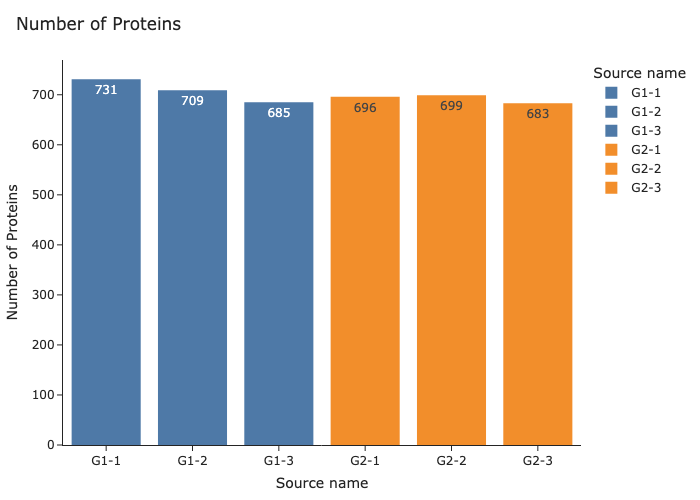

In [18]:
mm.pl.plot_id(mdata, modality="protein", colorby="factor value[condition]")

### Intensity distribution plot


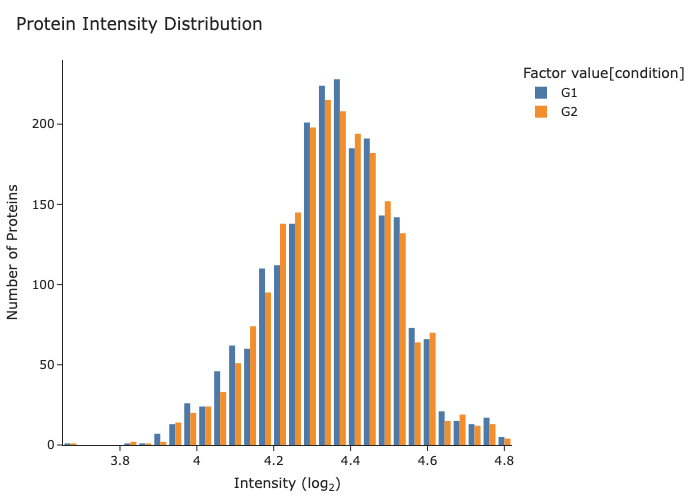

In [19]:
mm.pl.plot_intensity(mdata, modality="protein", groupby="factor value[condition]")

## Saving Processed MuData Object

You can save MuData object into an `h5mu` file.
This allows you to easily reload the processed data in future sessions without repeating the entire analysis pipeline.


In [20]:
mdata.write_h5mu("dia_lfq_PXD012988.h5mu")

## For DIA-NN without decoy

`DIA-NN` versions earlier than 2.0 **do not** include decoy features in the final report.tsv.

Also, even in `DIA-NN` version higher than 2.0, if the search settings in `DIA-NN` does not contain `--report-decoys`, the final will still lack decoy features.

As a result, **step-wise q-value estimation cannot be performed** and **`mm.pp.infer_protein()` cannot be applied** to `DIA-NN` version under 2.0.

Therefore, the protein groups reported directly by `DIA-NN` should be used without re-inferring them in msmu.

### Filtering - without decoy

For protein group–level q-values, use `Lib.PG.Q.Value` (when MBR is enabled) or `Global.PG.Q.Value` (when MBR is disabled) from the `DIA-NN` search results.


In [21]:
# Removing decoy features from DIA-NN output for mimicking data without decoy

mdata = mm.read_diann(identification_file=diann_idents)
del mdata["psm"].uns["decoy"]

mdata

MuData object with n_obs × n_vars = 6 × 5038
  uns:	'_cmd'
  1 modality
    psm:	6 × 5038
      var:	'proteins', 'peptide', 'stripped_peptide', 'filename', 'charge', 'peptide_length', 'rt', 'decoy', 'contaminant', 'PEP', 'q_value'
      uns:	'level', 'search_engine', 'quantification', 'label', 'acquisition', 'identification_file', 'quantification_file'
      varm:	'search_result'
      layers:	None

In [22]:
# Adding PG Q-value column for filtering
mdata = mm.pp.add_filter(mdata, modality="psm", column="q_value", keep="lt", value=0.01)
mdata = mm.pp.add_filter(
    mdata, modality="psm", on="varm", key="search_result", column="Lib.PG.Q.Value", keep="lt", value=0.01
)
mdata = mm.pp.apply_filter(mdata, modality="psm", on="var")

mdata

INFO - Applying var filters for psm: ['q_value_lt_0.01', 'Lib.PG.Q.Value_lt_0.01']


MuData object with n_obs × n_vars = 6 × 4999
  uns:	'_cmd'
  1 modality
    psm:	6 × 4999
      var:	'proteins', 'peptide', 'stripped_peptide', 'filename', 'charge', 'peptide_length', 'rt', 'decoy', 'contaminant', 'PEP', 'q_value'
      uns:	'level', 'search_engine', 'quantification', 'label', 'acquisition', 'identification_file', 'quantification_file', 'filter'
      varm:	'search_result', 'filter'
      layers:	None

### Normalization - without decoy

Once filtering is done, you can process and summarize the data to peptide and protein levels as shown below.


In [23]:
mdata = mm.pp.log2_transform(mdata, modality="psm")
mdata = mm.pp.normalize(mdata, modality="psm", method="median")

### Summarization - without decoy

Manually add protein group and peptide-type information from the `DIA-NN` search results into the peptide var:

- `protein_group` from `DIA-NN`'s `Protein.Group` (string value representing the protein group IDs associated with the peptide)
- `peptide_type` from `DIA-NN`'s `Proteotypic` (boolean value indicating whether the peptide is unique to a single protein group or shared among multiple protein groups).

No peptide filtering is performed at this stage.


In [24]:
mdata = mm.pp.to_peptide(mdata, calculate_q=False)

map_df = mdata["psm"].varm["search_result"][["Modified.Sequence", "Protein.Group", "Proteotypic"]]
map_df = map_df.drop_duplicates().set_index("Modified.Sequence")

mdata["peptide"].var["protein_group"] = mdata["peptide"].var_names.map(map_df["Protein.Group"])
mdata["peptide"].var["peptide_type"] = mdata["peptide"].var_names.map(map_df["Proteotypic"])
mdata["peptide"].var["peptide_type"] = ["unique" if x else "shared" for x in mdata["peptide"].var["peptide_type"]]

WARNING - Decoy data not found. Skipping decoy aggregation.
INFO - Building new peptide quantification data.


In [25]:
mdata = mm.pp.to_protein(mdata, top_n=3, rank_method="total_intensity", calculate_q=False)

INFO - Applying var filters for peptide: ['peptide_type_eq_unique']
WARNING - Decoy data not found. Skipping decoy aggregation.


In [26]:
mdata

MuData object with n_obs × n_vars = 6 × 6725
  uns:	'_cmd'
  3 modalities
    psm:	6 × 4999
      var:	'proteins', 'peptide', 'stripped_peptide', 'filename', 'charge', 'peptide_length', 'rt', 'decoy', 'contaminant', 'PEP', 'q_value'
      uns:	'level', 'search_engine', 'quantification', 'label', 'acquisition', 'identification_file', 'quantification_file', 'filter'
      varm:	'search_result', 'filter'
      layers:	None
    peptide:	6 × 969
      var:	'peptide', 'proteins', 'stripped_peptide', 'count_psm', 'PEP', 'protein_group', 'peptide_type'
      uns:	'level'
      layers:	None
    protein:	6 × 757
      var:	'count_psm', 'count_stripped_peptide', 'PEP'
      uns:	'level'
      layers:	None

## Citation

> Uszkoreit, J., Barkovits, K., Pacharra, S., Pfeiffer, K., Steinbach, S., Marcus, K., & Eisenacher, M. (2022). Dataset containing physiological amounts of spike-in proteins into murine C2C12 background as a ground truth quantitative LC-MS/MS reference. _Data in Brief_, 43, 108435.

> Demichev, V., Messner, C. B., Vernardis, S. I., Lilley, K. S., & Ralser, M. (2020). DIA-NN: neural networks and interference correction enable deep proteome coverage in high throughput. Nature methods, 17(1), 41-44.
